In [1]:
#####let's see the output

In [257]:
from lics_unwrap import *
import re, os, glob
import xarray as xr
from scipy.constants import speed_of_light
import h5py
import numpy as np
import cmcrameri.cm as cmc
import lics_tstools as lts

In [7]:
frame=['014A_05232_242525','021D_05266_252525', '116A_05207_252525']

cumfile=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/ranges/inter/inter2016-2020/{frame[1]}/TS_GEOCml10GACOSmask/cum.h5'
framefile=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/ranges/inter/inter2016-2020/{frame[1]}'
cuma = xr.load_dataset(cumfile)

In [6]:
cuma

<xarray.Dataset>
Dimensions:        (phony_dim_0: 208, phony_dim_1: 469, phony_dim_2: 386,
                    phony_dim_3: 207)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/22)
    bperp          (phony_dim_0) float64 -84.0 -103.0 -90.0 ... 118.0 -126.0
    coh_avg        (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    corner_lat     float64 39.64
    corner_lon     float64 35.33
    cum            (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    gap            (phony_dim_3, phony_dim_1, phony_dim_2) int8 0 0 0 ... 0 0 0
    ...             ...
    resid_rms      (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    vel            (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    vintercept     (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    tide           (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    iono           (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    external_data  (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan

In [9]:
tide_vel=os.path.join(framefile, 'tide.vel')
cuma.vel=can you create a cum_tide_vel and add the tide_vel values there with the cum.vel size?

In [76]:
vel_file=os.path.join(framefile, frame[1]+'.vel_filt.mskd.geo.tif')

In [77]:
vel_file

'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/ranges/inter/inter2016-2020/021D_05266_252525/021D_05266_252525.vel_filt.mskd.geo.tif'

In [161]:
import os
import numpy as np
import xarray as xr

# File paths
frame = ['014A_05232_242525','021D_05266_252525', '116A_05207_252525']
cumfile = f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/ranges/inter/inter2016-2020/{frame[1]}/TS_GEOCml10GACOSmask/cum.h5'
framefile = f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/ranges/inter/inter2016-2020/{frame[1]}'
tide_vel_file = os.path.join(framefile, 'tide.vel')
iono_vel_file = os.path.join(framefile, 'iono.vel')
gacos_vel_file = os.path.join(framefile, 'gacos.vel')
vel_file=os.path.join(framefile, frame[1]+'.vel_filt.mskd.eurasia.geo.tif')
# Load cumulative displacement dataset
cuma = xr.load_dataset(cumfile)

# Load tide.vel assuming it's a binary float32 file with the same shape as cuma.vel
shape = cuma.vel.shape
tide_data = np.fromfile(tide_vel_file, dtype='float32').reshape(shape)
iono_data = np.fromfile(iono_vel_file, dtype='float32').reshape(shape)
gacos_data = np.fromfile(gacos_vel_file, dtype='float32').reshape(shape)
vlos = lts.load_tif2xr(vel_file)
# # Create a new DataArray for tide correction with the same coordinates as cuma.vel
# tide_da = xr.DataArray(
#     tide_data,
#     coords=cuma.vel.coords,
#     dims=cuma.vel.dims,
#     name='tide_vel'
# )

# # Add tide correction to cumulated velocity
# cum_tide_vel = cuma.vel + tide_da

# # Optionally, assign to cuma for easy access
# cuma['cum_tide_vel'] = cum_tide_vel


In [162]:
# Add tide_vel directly as a new variable in the dataset
cuma['tide_vel'] = xr.DataArray(
    tide_data,
    coords=cuma.vel.coords,
    dims=cuma.vel.dims
)

In [163]:
frame[1]

'021D_05266_252525'

In [164]:
vlos_eurasia = lts.generate_pmm_velocity(frame[1], 'Eurasia', 'GEOC')
vlos_eurasia

assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


<xarray.DataArray (lat: 4694, lon: 3867)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]])
Coordinates:
    spatial_ref  int64 0
  * lon          (lon) float64 35.33 35.33 35.33 35.33 ... 39.19 39.19 39.2 39.2
  * lat          (lat) float64 39.65 39.65 39.64 39.64 ... 34.96 34.95 34.95
Attributes:
    AREA_OR_POINT:     Point
    TIFFTAG_DATETIME:  2023:02:06 19:15:00
    TIFFTAG_SOFTWARE:  Created with GAMMA Software www.gamma-rs.ch data2geoti...
    _FillValue:        0.0
    scale_factor:      1.0
    add_offset:        0.0

In [165]:
vlos_eurasia_reshaped = vlos_eurasia.interp_like(vlos)

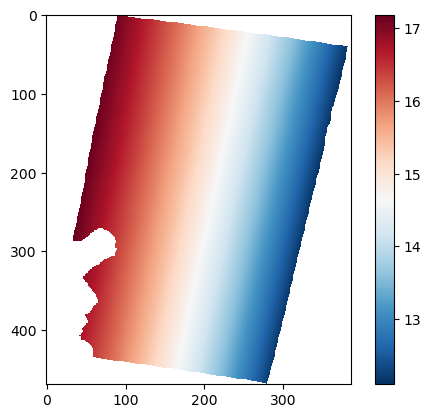

In [166]:
plt.imshow(vlos_eurasia_reshaped.data, cmap='RdBu_r')
plt.colorbar()

In [216]:
# print('\n Fixing to the reference area selected at step 16 \n')
# infodir = os.path.join(tsdir, 'info')
# reffile = os.path.join(infodir, '16ref.txt')
# if not os.path.exists(reffile):
import re

# Extract the string from the array
refarea = cuma.refarea.item()  # convert numpy scalar to plain string

# Split and convert to integers
refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]
vlos_all_corrected.values = vlos_all_corrected.values - np.nanmean(vlos_all_corrected.values[refy1:refy2, refx1:refx2])

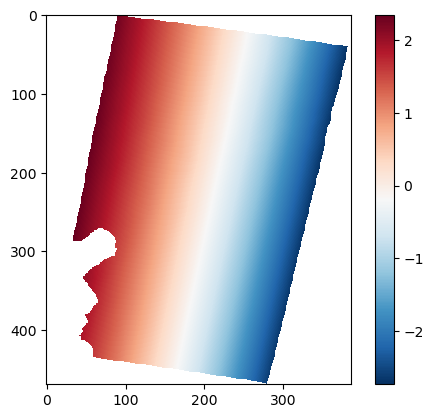

In [218]:
plt.imshow(vlos_all_corrected.values, cmap='RdBu_r')
plt.colorbar()

In [175]:
np.shape(vlos.data)

(469, 386)

In [178]:
print(np.shape(vlos.data), np.shape(gacos_data), np.shape(tide_data), np.shape(iono_data))

(469, 386) (469, 386) (469, 386) (469, 386)


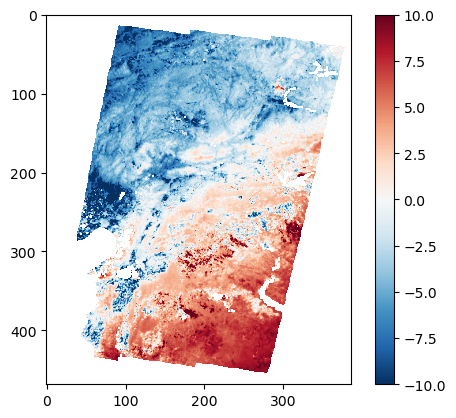

In [228]:
plt.imshow(vlos.data-tide_data-iono_data-vlos_all_corrected.data+gacos_data, cmap='RdBu_r', vmin=-10, vmax=10)
plt.colorbar()

In [235]:
cuma

<xarray.Dataset>
Dimensions:        (phony_dim_0: 208, phony_dim_1: 469, phony_dim_2: 386,
                    phony_dim_3: 207)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/23)
    bperp          (phony_dim_0) float64 -84.0 -103.0 -90.0 ... 118.0 -126.0
    coh_avg        (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    corner_lat     float64 39.64
    corner_lon     float64 35.33
    cum            (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    gap            (phony_dim_3, phony_dim_1, phony_dim_2) int8 0 0 0 ... 0 0 0
    ...             ...
    vel            (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    vintercept     (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan
    tide           (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    iono           (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    external_data  (phony_dim_0, phony_dim_1, phony_dim_2) float32 nan ... nan
    tide_vel       (phony_dim_1, phony_dim_2) float32 nan nan nan ... nan nan

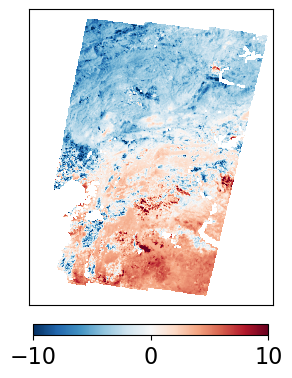

In [233]:
# Get the refarea string from cuma
refarea = cuma.refarea.item()
refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]

# Compute symmetric color scale from percentiles
data = vlos.data
v = np.nanpercentile(data, [2, 98])
lim = max(abs(v[0]), abs(v[1]))
vmin = -10
vmax = 10

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(data, cmap='RdBu_r', vmin=vmin, vmax=vmax)
ax.set_xticks([])
ax.set_yticks([])

# Add black rectangle for reference area
rect = Rectangle((refx1, refy1), refx2 - refx1, refy2 - refy1,
                 linewidth=1.5, edgecolor='black', facecolor='none')
ax.add_patch(rect)

# Add horizontal colorbar
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.5)
cbar.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

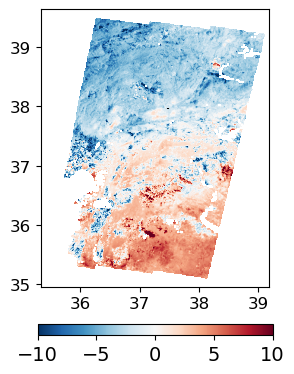

In [249]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import re

# Get shape and metadata
ny, nx = data.shape
corner_lon = cuma.corner_lon.item()
corner_lat = cuma.corner_lat.item()
post_lon = cuma.post_lon.item()
post_lat = cuma.post_lat.item()

# Create coordinate arrays
x_coords = corner_lon + np.arange(nx) * post_lon
y_coords = corner_lat + np.arange(ny) * post_lat
if post_lat < 0:
    y_coords = y_coords[::-1]
# Set extent for imshow (left, right, bottom, top)
extent = [x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]]

# Get refarea and convert to geo coords
refarea = cuma.refarea.item()
refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]
ref_lon = corner_lon + np.array([refx1, refx2]) * post_lon
ref_lat = corner_lat + np.array([refy1, refy2]) * post_lat

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(data, cmap='RdBu_r', vmin=vmin, vmax=vmax, extent=extent)
# ax.set_xlabel("Longitude (°)")
# ax.set_ylabel("Latitude (°)")
ax.tick_params(labelsize=12)

# Add black reference rectangle (geo-aligned)
rect = Rectangle((ref_lon[0], ref_lat[0]), ref_lon[1] - ref_lon[0], ref_lat[1] - ref_lat[0],
                 linewidth=1.5, edgecolor='black', facecolor='none')
ax.add_patch(rect)

# Add horizontal colorbar
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.1, shrink=0.5)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()


In [251]:
import xarray as xr

# Create longitude and latitude arrays
lons = corner_lon + np.arange(nx) * post_lon
lats = corner_lat + np.arange(ny) * post_lat

# Flip latitude axis if necessary (if post_lat < 0)
if post_lat < 0:
    lats = lats[::-1]
    data = data[::-1, :]  # flip data to match increasing latitude

# Create DataArray
grid = xr.DataArray(
    data,
    coords={"lat": lats, "lon": lons},
    dims=["lat", "lon"],
    name="z"
)


In [258]:
region

[35.334499999999998, 39.1845, 34.962167000000001, 39.642167000000001]

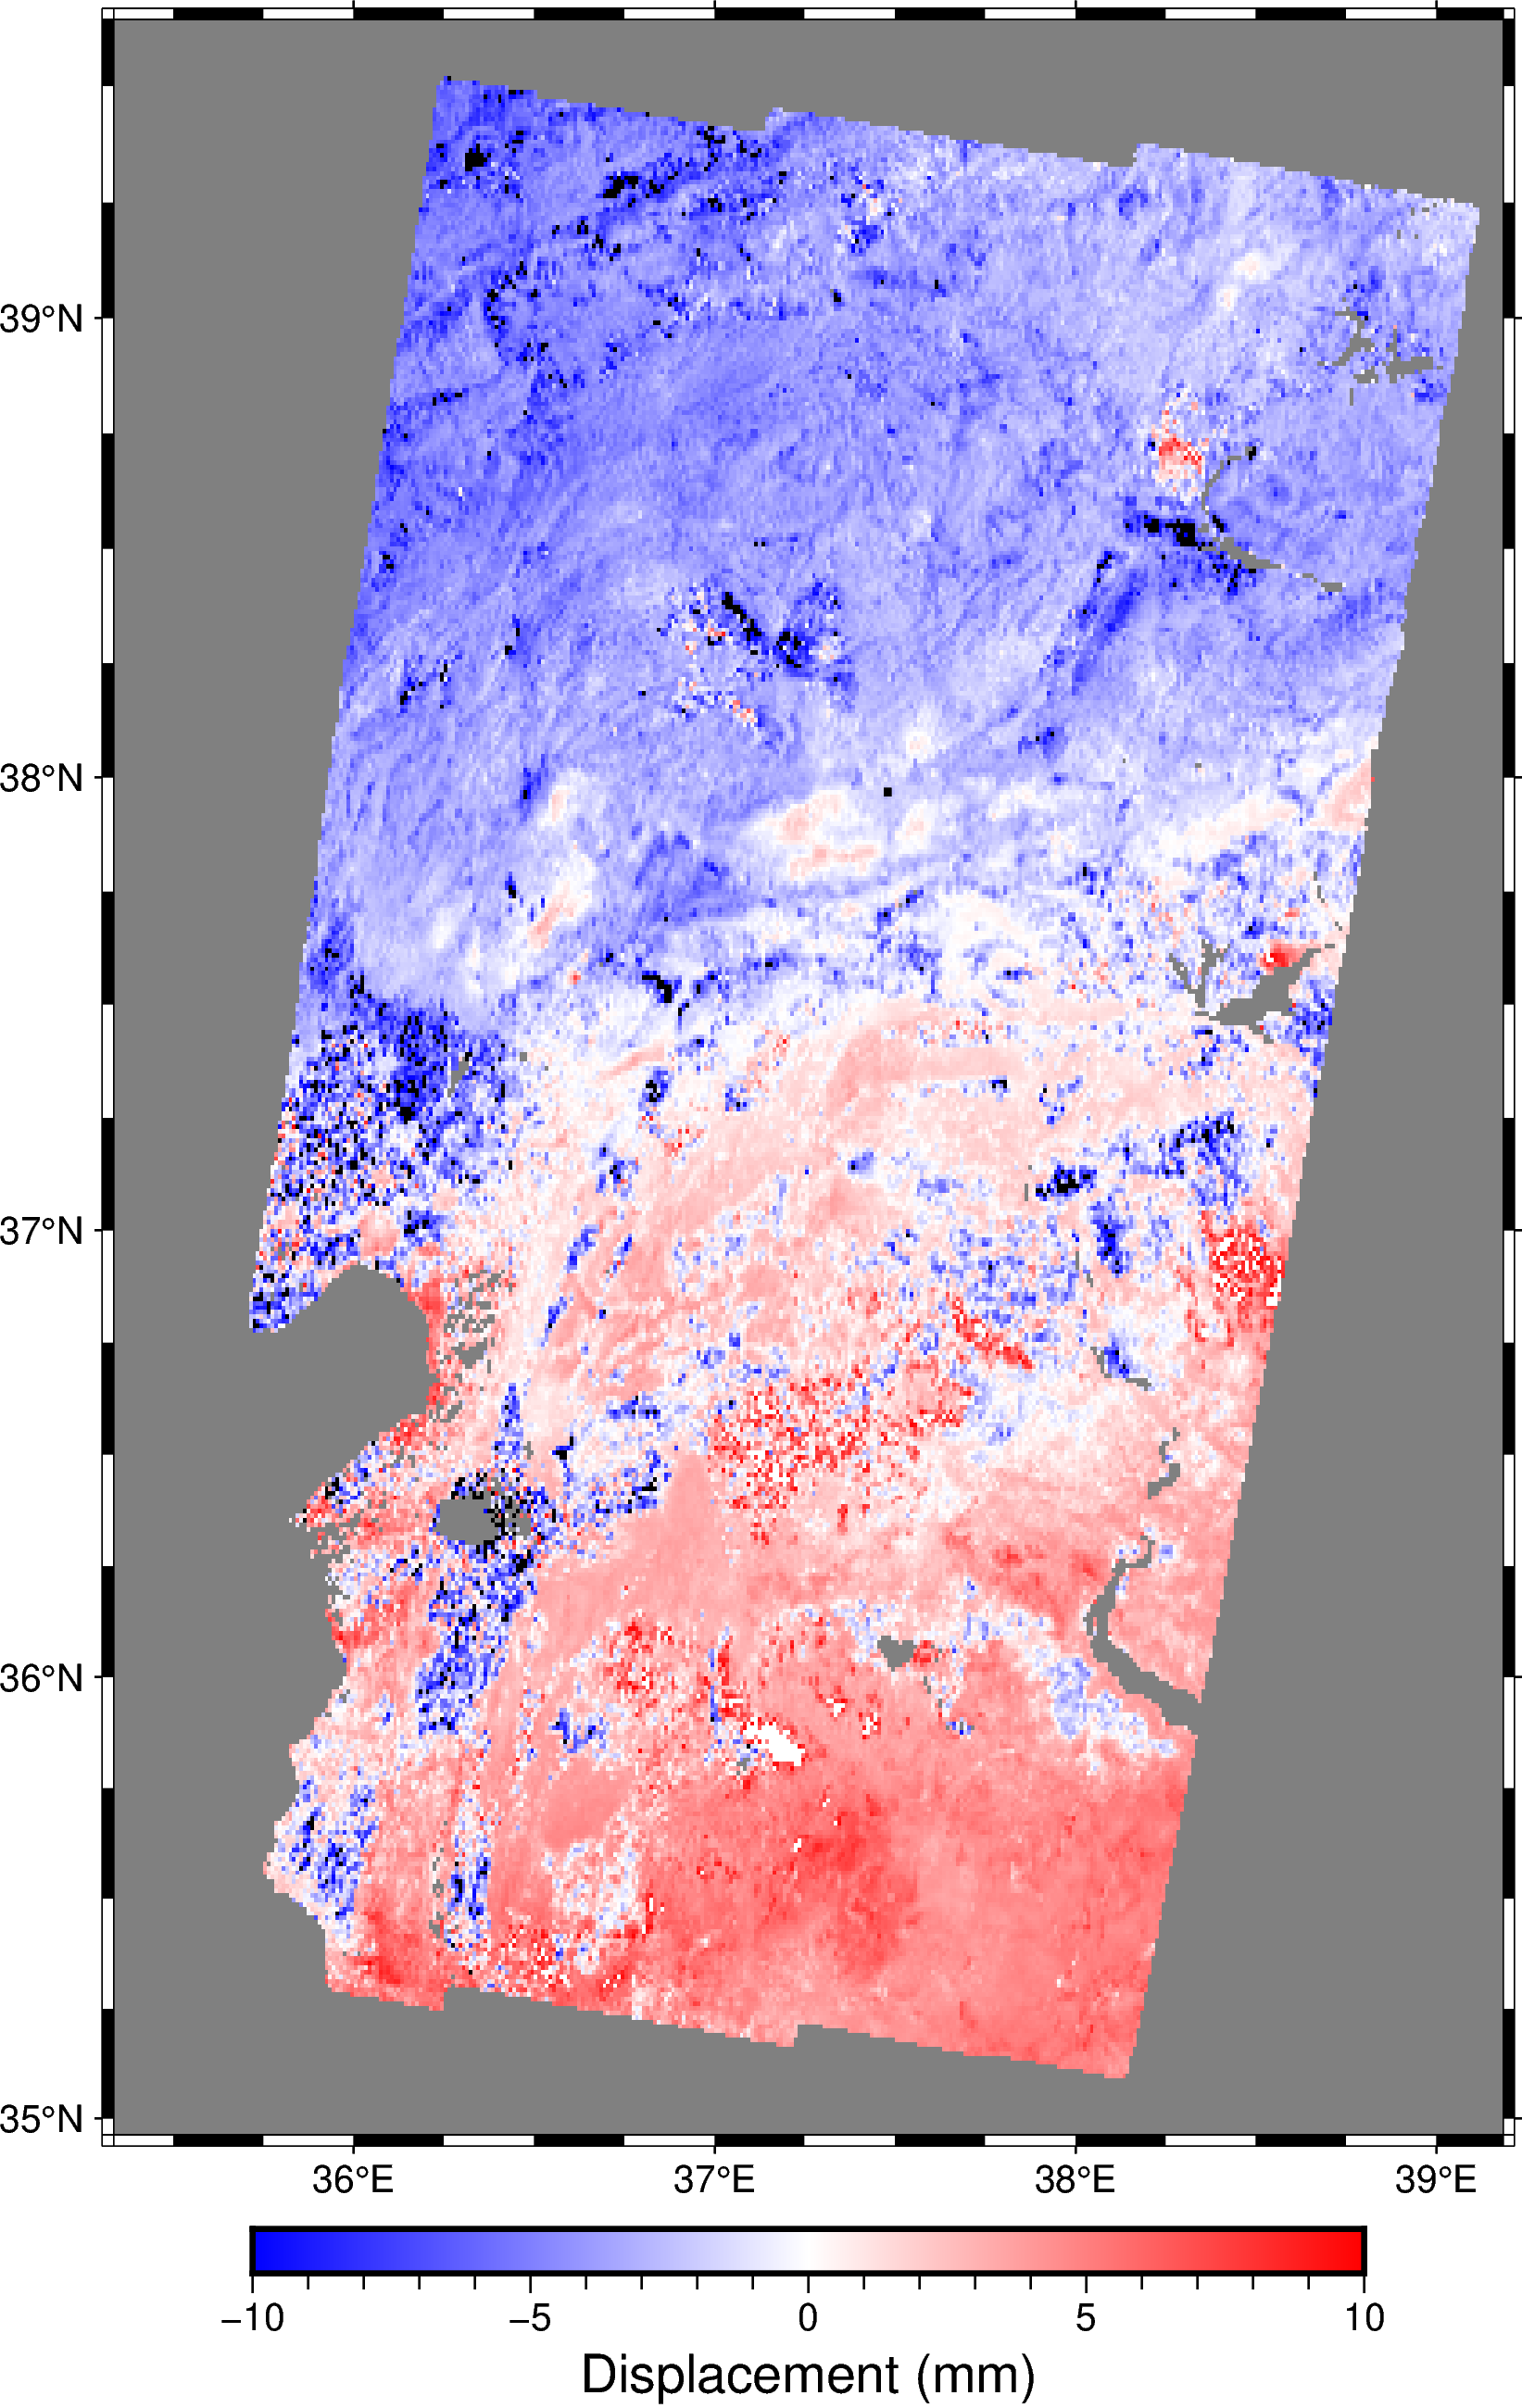

In [252]:
import pygmt

fig = pygmt.Figure()

# Define region from data extent
region = [lons[0], lons[-1], lats[0], lats[-1]]

# Define color range (same as vmin/vmax)
cmap_range = [vmin, vmax]

# Make colormap (you can replace with your own CPT)
pygmt.makecpt(cmap="polar", series=cmap_range)

# Plot grid
fig.grdimage(grid=grid, region=region, projection="M5i", frame=True, cmap=True)

# Plot rectangle (refarea in lon/lat)
ref_lon = corner_lon + np.array([refx1, refx2]) * post_lon
ref_lat = corner_lat + np.array([refy1, refy2]) * post_lat
rectangle = [ref_lon[0], ref_lat[0], ref_lon[1], ref_lat[1]]
fig.plot(x=[rectangle[0], rectangle[2], rectangle[2], rectangle[0], rectangle[0]],
         y=[rectangle[1], rectangle[1], rectangle[3], rectangle[3], rectangle[1]],
         pen="1p,black")

# Add colorbar
fig.colorbar(frame='x+l"Displacement (mm)"')

# Show the figure
fig.show()


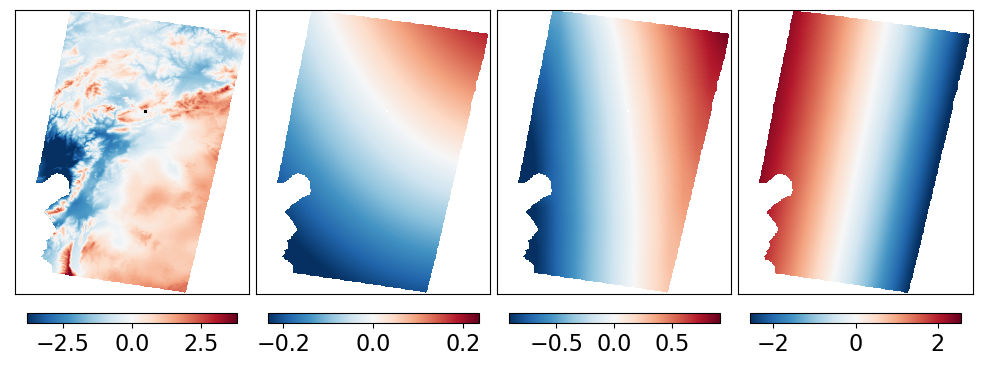

In [227]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
# plt.style.use('ac')  # clean, old-school
import seaborn as sns
sns.set_context("paper")
plt.style.use('default')  #


# Set up 1x4 subplots
fig, axs = plt.subplots(1, 4, figsize=(10, 4))
datasets = [gacos_data, tide_data, iono_data, vlos_all_corrected.data]
titles = ['GACOS', 'Tides', 'Ionosphere', 'PMM-EU']

for ax, data, title in zip(axs, datasets, titles):
    # Calculate individual color scale limits using percentiles
    v = np.nanpercentile(data, [2, 98])
    lim = max(abs(v[0]), abs(v[1]))
    vmin = -lim
    vmax = lim


    # Plot with individual scaling
    im = ax.imshow(data, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    # ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(True)
    if title == 'GACOS':
        # Plot reference rectangle
        rect = Rectangle((refx1, refy1), refx2 - refx1, refy2 - refy1,
                         linewidth=1.5, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

    # Add individual horizontal colorbar
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.9)
    cbar.ax.tick_params(labelsize=16)
plt.tight_layout()
plt.subplots_adjust(wspace=0.03)
plt.savefig('corrections.png')


In [253]:
import xarray as xr

def to_pygmt_grid(data, corner_lon, corner_lat, post_lon, post_lat):
    ny, nx = data.shape
    lons = corner_lon + np.arange(nx) * post_lon
    lats = corner_lat + np.arange(ny) * post_lat
    if post_lat < 0:
        lats = lats[::-1]
        data = data[::-1, :]
    return xr.DataArray(data, coords={"lat": lats, "lon": lons}, dims=["lat", "lon"])


In [254]:
grids = [
    to_pygmt_grid(gacos_data, corner_lon, corner_lat, post_lon, post_lat),
    to_pygmt_grid(tide_data, corner_lon, corner_lat, post_lon, post_lat),
    to_pygmt_grid(iono_data, corner_lon, corner_lat, post_lon, post_lat),
    to_pygmt_grid(vlos_all_corrected.data, corner_lon, corner_lat, post_lon, post_lat),
]
titles = ['GACOS', 'Tides', 'Ionosphere', 'PMM-EU']
